# <span style="color:black; font-weight:bold;">Million breast cancer alignment Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Million breast cancer data used in the tutorial are available at [Big1.h5ad](https://drive.google.com/file/d/1Swuhz3syR0xVK-ZhrkxuT-1ZB85hAhBb/view?usp=sharing) and [Big2.h5ad](https://drive.google.com/file/d/1I0qr0GDNMYI6bYO1j0OpvsciNHhT2c-2/view?usp=sharing).
In this tutorial we apply MAPS to align Million cell breast cancer dataset.

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Big1(ST)</span>: 892,966 cells and 280 genes   
+ <span style="color:black; font-weight:bold;">Big2(ST)</span>: 885,523 cells and 280 genes  

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading Million cell breast cancer data (Xenium)</span>

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/Big_xenium/Big1.h5ad')
source_adata.obs['batch']='Breast_cancer_rep1'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/Big_xenium/Big2.h5ad')
target_adata.obs['batch']='Breast_cancer_rep2'

### Rotate and translate the source data 

In [5]:
rotate_and_translate_spatial(source_adata, angle_deg=60, dx=5000, dy=-5000)

## <span style="color:black; font-weight:bold;">Spatial mapping of the Million cell breast cancer data before alignment</span>

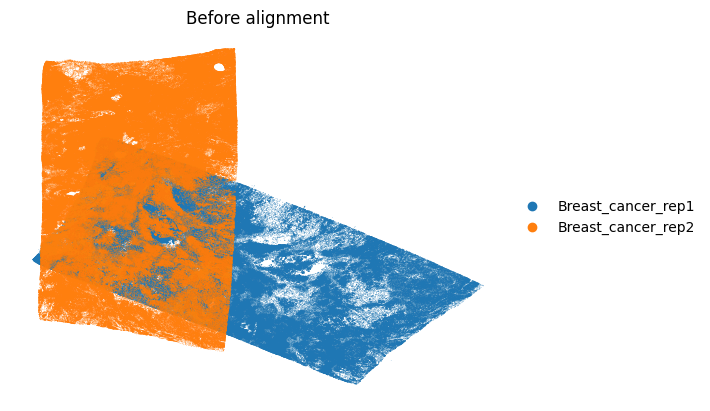

In [6]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='Before alignment',size=0.5,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor  

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale = Rigid_alignment(source, target, epochs=2000, sample_size=20000, enable_scale=False, device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 2000/2000 [00:37<00:00, 52.73it/s, Loss=47.99, Scale=1.000, Rot=-61.95°, Trans=(-4667.0, 5857.4)]


Peak GPU memory usage: 4.907 GB
Scale factor: 1.000, Rotation angle: -62.10°, Translation (x, y): (-4666.69, 5857.10)
CPU times: user 29.8 s, sys: 10.8 s, total: 40.6 s
Wall time: 41 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the Million cell breast cancer after alignment</span>

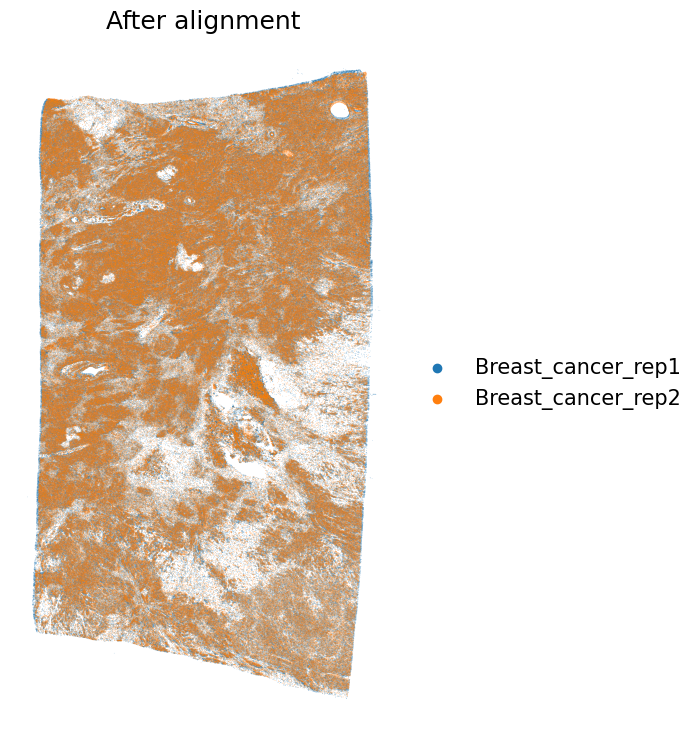

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,9)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='After alignment',size=0.5,alpha=0.7,frameon=False)